# 12 — Factor Risk & Attribution

**Chain position:** … → Construction → Risk → `Factor Risk`

Notebook 11 asked what the book can lose. This one asks a different question, and it is the
one a risk committee actually opens with:

> **When this book loses money, what will it have been a bet on?**

A covariance matrix of eleven tickers cannot answer that. It knows the positions co-move; it
does not know *why*. Notebook 11's `concentration()` already reports that one eigenvalue eats
most of the cross-sectional variance — this notebook puts a **name** on that eigenvalue.

### What is built here

A cross-sectional style factor model in the Barra tradition, from the universe itself:

1. **Exposures** `X` — each name's standardised score on size, value, momentum, low-vol,
   quality and growth.
2. **Factor returns** `f` — estimated on every date by weighted cross-sectional regression of
   name returns on exposures. A *regression*, not a portfolio sort: it gives the return to a
   unit exposure of each style holding the others fixed.
3. **Factor covariance** `F` — exponentially weighted, so a two-year estimate still reacts to
   last quarter.
4. **Specific variance** `D` — what is left once every style is accounted for.

Total risk is `w'(XFX' + D)w`, and the split between the two terms is the answer.

### The defect this notebook also fixes

Every Sharpe ratio in the chain was computed against **zero**. At an Indian risk-free rate near
6.25% and a book at low single-digit volatility, that is not a rounding error — it is the whole
distance between beating cash and not. `mkt.perf` recomputes everything on an excess-return
basis and `perf.assert_excess_return_basis` refuses a performance block that has forgotten to.

### Point-in-time honesty (trap #4, again)

Momentum, low-volatility and size come from prices and are point-in-time by construction. Value,
quality and growth come from `yfinance` statements, which have no point-in-time history — so
their exposures are held at today's values across the estimation window.

For an *alpha* model that would be fatal, and notebook 07 refuses to do it. For a *risk* model
it is a much smaller sin: the object being estimated is a covariance, not an expected return,
and a name's quality decile is far more persistent than its return. It is still an assumption,
so `factors.assert_factor_pit` labels every style and makes the split impossible to lose.

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

_root = Path.cwd()
while not (_root / "mkt").is_dir() and _root != _root.parent:
    _root = _root.parent
sys.path.insert(0, str(_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mkt
from mkt import (config, fetch, align, dashboard, factors as fx, perf,
                 risk as rk, portfolio as pf, indicators as ind, viz)

REFRESH = False
mkt.bootstrap(refresh=REFRESH)

book_path = config.OUTPUT_DIR / "portfolio_book.csv"
if not book_path.exists():
    raise FileNotFoundError(f"{book_path} not found -- run notebook 10 first")
screen_path = config.OUTPUT_DIR / "nifty50_screen.csv"
if not screen_path.exists():
    raise FileNotFoundError(f"{screen_path} not found -- run notebook 06 first")

raw = pd.read_csv(book_path).set_index("ticker")
book = pd.DataFrame({"side": raw["side"], "weight": raw["target_weight"],
                     "beta": raw["beta"]})
book["beta_contrib"] = book["weight"] * book["beta"]
book.attrs["method"] = "beta-neutral"
sectors = raw["sector"]
CAPITAL = config.DEFAULT_CAPITAL

screen = pd.read_csv(screen_path).set_index("ticker")
print(f"book: {len(book)} names | gross {book['weight'].abs().sum():.3f} | "
      f"net {book['weight'].sum():+.3f} | net beta {book['beta_contrib'].sum():+.4f}")
print(f"universe for factor estimation: {len(screen)} names")

mkt v2.0.0 | run 2026-09-10 02:06 | REFRESH=False | cache=G:\stock market analysis\data\cache
book: 11 names | gross 1.000 | net -0.082 | net beta +0.0122
universe for factor estimation: 50 names


## 1. The estimation panel

The factor model is estimated on the **whole Nifty 50**, not on the eleven names in the book. A
cross-sectional regression on eleven observations and six factors is not an estimate, it is an
interpolation — `config.FACTOR_MIN_NAMES` refuses it. The book's exposures are then read off the
universe-wide model.

In [2]:
frames_u, failures = fetch.price_histories(list(screen.index), period="3y")
if failures:
    display(pd.DataFrame(failures, columns=["ticker", "reason"]))

panel_u = align.align_to_calendar(fetch.close_frame(frames_u), calendar="NSE")
align.assert_alignment(panel_u, max_nan_pct=8.0, label="factor estimation panel")
rets_u = align.to_returns(panel_u).dropna(how="all")

# Book-level panel and covariance, for the cross-checks in section 5.
have = [t for t in book.index if t in panel_u.columns]
rets = rets_u[have]
cov = rk.shrunk_cov(rets.tail(config.COV_LOOKBACK_DAYS))
w = book["weight"].reindex(have)

bench_px = fetch.price_history(config.BENCHMARK, period="3y", quiet=True)["Close"]
bench_rets = bench_px.reindex(panel_u.index).ffill().pct_change().dropna()
port_rets = rk.portfolio_returns(w, rets)

print(f"panel {panel_u.shape[0]} sessions x {panel_u.shape[1]} names, "
      f"as of {panel_u.index[-1].date()}")
print(f"book names with prices: {len(have)}/{len(book)}")

  fetched 50/50 tickers in 1s


panel 739 sessions x 50 names, as of 2026-09-09
book names with prices: 11/11


## 2. Exposures

Standardised within the cross-section and winsorised at ±3σ, so an exposure of +1 always means
"one cross-sectional standard deviation" and the six styles are comparable with each other.

The order matters: winsorising the **z-score** rather than the raw value keeps the scale honest.
Clipping raw values first lets one outlier set the scale and then be pulled back in, compressing
everyone else towards zero.

In [3]:
X = fx.build_exposures(screen, panel_u)
display(fx.exposure_report(X).round(3))

pit = fx.assert_factor_pit(X, "Nifty 50 exposures")
display(pit)
print(f"  {pit.attrs['result']}")
if X.attrs.get("dropped"):
    print(f"  dropped (source column unavailable): {X.attrs['dropped']}")

,basis,mean,std,min,max,coverage_%,n_at_winsor_bound
factor,,,,,,,
size,static (trap #4),-0.00,1.00,-1.88,2.54,100.00,0
value,static (trap #4),-0.07,0.53,-0.47,3.00,100.00,1
momentum,point-in-time,-0.00,1.00,-2.11,2.84,100.00,0
low_vol,point-in-time,0.00,1.00,-2.56,1.28,100.00,0
quality,static (trap #4),-0.04,0.84,-1.15,3.00,100.00,2
growth,static (trap #4),-0.05,0.71,-1.34,3.00,100.00,1


,point_in_time,basis
factor,,
size,False,"today's statements, held constant"
value,False,"today's statements, held constant"
momentum,True,prices
low_vol,True,prices
quality,False,"today's statements, held constant"
growth,False,"today's statements, held constant"


  2 point-in-time, 4 static styles


## 3. Factor returns

Weighted least squares on each date, weights proportional to √(market cap) — the Barra
convention, sitting between equal weighting (where fifty small names outvote the index) and cap
weighting (where three names decide every factor return).

The intercept is the **market** factor: the return common to every name once styles are held
flat. Including it is what makes the style returns interpretable as *relative* bets rather than
as disguised market exposure.

The `t_stat` column describes **this sample**. It is deliberately not fed back into
`score.TECHNICAL_SPEC` — fitting weights on the sample that produced them is the loop notebook 07
exists to refuse.

In [4]:
dates = rets_u.index[280:]
exposures = fx.exposure_history(panel_u, screen, dates)
caps = pd.to_numeric(screen["market_cap"], errors="coerce")

F, U, R2 = fx.estimate_factor_returns(exposures, rets_u.reindex(dates), weights=caps)
print(f"estimated on {len(F)} dates | mean cross-sectional R² = {R2.mean():.3f}")
print("a cross-sectional R² near 0.2-0.4 is normal: most of a single name's daily move is "
      "idiosyncratic, which is the point of the specific-risk term.")

summary = fx.factor_return_summary(F)
display(summary.round(3))

estimated on 457 dates | mean cross-sectional R² = 0.208
a cross-sectional R² near 0.2-0.4 is normal: most of a single name's daily move is idiosyncratic, which is the point of the specific-risk term.


,ann_return_%,ann_vol_%,t_stat,sharpe,hit_rate_%,n_obs
factor,,,,,,
market,2.12,13.97,0.20,0.15,49.89,457
momentum,-2.09,5.01,-0.56,-0.42,50.11,457
low_vol,2.10,8.84,0.32,0.24,49.45,457
size,-0.17,3.56,-0.06,-0.05,50.33,457
value,-4.50,9.77,-0.62,-0.46,48.80,457
quality,-2.54,4.92,-0.70,-0.52,47.27,457
growth,9.29,6.60,1.90,1.41,50.77,457


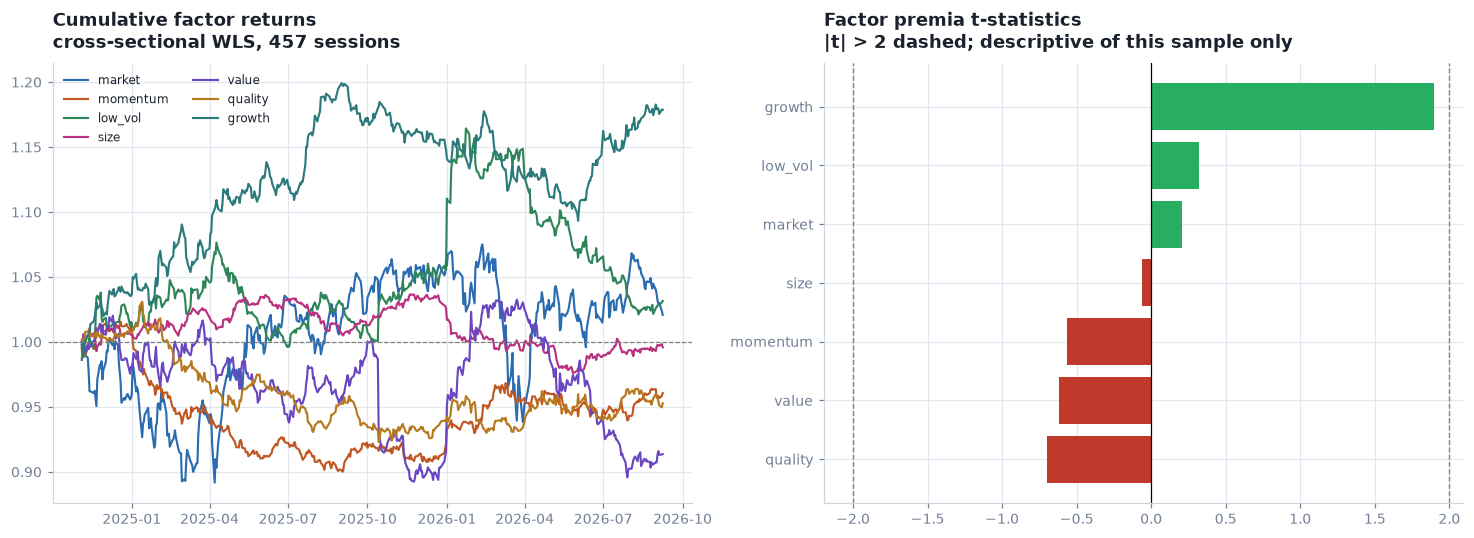

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5))

cum = (1 + F).cumprod()
for c in cum.columns:
    axes[0].plot(cum.index, cum[c], label=c, lw=1.4)
axes[0].axhline(1.0, color="grey", lw=0.8, ls="--")
axes[0].legend(fontsize=8, ncol=2)
viz.title(axes[0], "Cumulative factor returns",
          f"cross-sectional WLS, {len(F)} sessions")

s = summary["t_stat"].sort_values()
colors = ["#c0392b" if v < 0 else "#27ae60" for v in s]
axes[1].barh(s.index, s.values, color=colors)
for x in (-2, 2):
    axes[1].axvline(x, color="grey", lw=0.9, ls="--")
axes[1].axvline(0, color="black", lw=0.8)
viz.title(axes[1], "Factor premia t-statistics",
          "|t| > 2 dashed; descriptive of this sample only")
plt.tight_layout()
viz.save(fig, "12_factor_returns")
plt.show()

## 4. What is the book a bet on?

`net_exposure` is `X'w`. A book that is beta-neutral by construction can still carry a large net
style exposure — and that is the bet nobody wrote down.

`variance_contrib` sums **exactly** to the systematic variance, which is what makes the
percentage column trustworthy rather than indicative.

In [6]:
F_cov = fx.factor_covariance(F)
spec_var = fx.specific_variance(U)
print(f"factor covariance: {F_cov.attrs['method']}, {F_cov.attrs['n_obs']} observations")
print(f"specific variance: {spec_var.attrs['n_backfilled']} name(s) backfilled to the median")

exposures_book = fx.factor_exposures_of_book(w, X, F_cov)
display(exposures_book.round(4))

dec = fx.decompose_risk(w, X, F_cov, spec_var)
display(pd.DataFrame([dec]).T.rename(columns={0: "value"}))
print(f"\nsystematic {dec['systematic_share_%']:.1f}% / specific {dec['specific_share_%']:.1f}%")
print("A market-neutral book that is mostly systematic has not removed risk -- "
      "it has changed which risk it holds.")

factor covariance: EWMA (halflife 126 periods), 457 observations
specific variance: 0 name(s) backfilled to the median


,net_exposure,factor_vol_%,variance_contrib,pct_of_systematic
size,0.74,3.50,0.00,8.69
momentum,0.64,4.86,0.00,43.82
growth,0.34,6.31,0.00,21.22
low_vol,0.31,8.41,0.00,27.12
value,-0.09,9.64,-0.00,-1.27
quality,-0.03,4.78,0.00,0.43


,value
total_vol_%,7.67
systematic_vol_%,4.47
specific_vol_%,6.24
systematic_share_%,33.87
specific_share_%,66.13
n_names,11
n_factors,6
factor_cov_method,EWMA (halflife 126 periods)



systematic 33.9% / specific 66.1%
A market-neutral book that is mostly systematic has not removed risk -- it has changed which risk it holds.


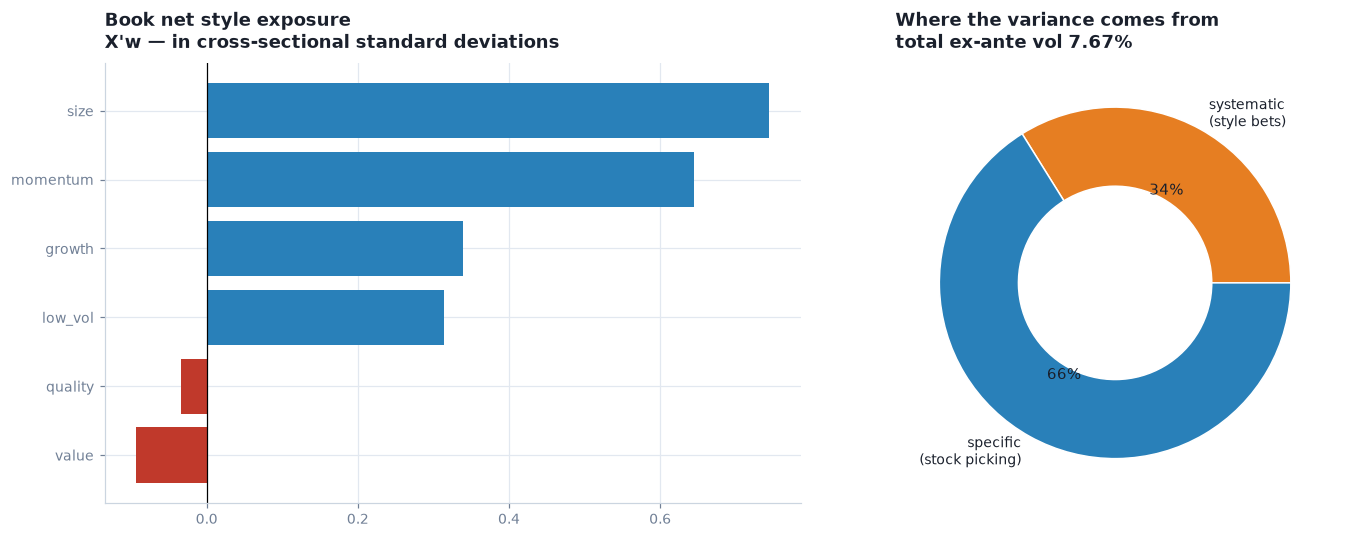

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5))

e = exposures_book["net_exposure"].sort_values()
axes[0].barh(e.index, e.values,
             color=["#c0392b" if v < 0 else "#2980b9" for v in e])
axes[0].axvline(0, color="black", lw=0.8)
viz.title(axes[0], "Book net style exposure",
          "X'w — in cross-sectional standard deviations")

parts = [max(dec["systematic_share_%"], 0), max(dec["specific_share_%"], 0)]
axes[1].pie(parts, labels=["systematic\n(style bets)", "specific\n(stock picking)"],
            autopct="%1.0f%%", colors=["#e67e22", "#2980b9"],
            wedgeprops={"width": 0.45, "edgecolor": "white"})
viz.title(axes[1], "Where the variance comes from",
          f"total ex-ante vol {dec['total_vol_%']:.2f}%")
plt.tight_layout()
viz.save(fig, "12_risk_decomposition")
plt.show()

## 5. Cross-check: does the model describe *this* book?

The same discipline notebook 11 applies to VaR. A structured covariance is meant to be better
**conditioned** than the sample, not to describe a different portfolio. If the model says 4% and
the book realised 12%, something is wrong with the exposures, the factor returns or the
annualisation — and that is a bug, not a view.

Note the parameter counts. The factor model estimates a handful of factor variances plus one
residual variance per name; the sample covariance estimates `n(n+1)/2`. That ratio is the entire
argument for using one.

In [8]:
model_cov = fx.factor_model_cov(X, F_cov, spec_var)
display(fx.assert_model_vs_sample(w, model_cov, rets_u, tolerance_ratio=2.0,
                                  label="factor model"))
print(f"factor model parameters: {model_cov.attrs['n_parameters']} "
      f"vs sample covariance's {model_cov.attrs['n_sample_parameters']}")

,model_vol_%,realised_vol_%,ratio,tolerance,n_obs,result
0,7.67,7.34,1.05,2.00,737,factor model agrees with the realised return p...


factor model parameters: 71 vs sample covariance's 1275


## 6. Performance, on an excess-return basis

The chain reported Sharpe against **zero**. Every ratio below is computed on excess returns and
the rate used travels with the number.

`sharpe_correction` prints the size of the defect deliberately — the gap is roughly `rf / vol`,
and on a low-volatility book it is very large.

There is one defensible exception: a genuinely market-neutral book funded on collateral earns the
rate on its cash, so its spread is already excess. That case is handled by asking for it
(`allow_zero_rf=True`), never by silence.

In [9]:
rf, rf_source = perf.risk_free_annual()
print(f"risk-free {rf:.2f}% — {rf_source}")

display(perf.sharpe_correction(port_rets, rf).round(3))

stats = perf.perf_stats(port_rets, rf_annual_pct=rf)
rel = perf.relative_stats(port_rets, bench_rets, rf)

display(pd.DataFrame({"book": stats}).T[
    ["years", "cagr_%", "excess_cagr_%", "ann_vol_%", "downside_dev_%", "sharpe",
     "sortino", "calmar", "omega", "max_drawdown_%", "hit_rate_%", "skew",
     "excess_kurtosis", "tail_ratio", "rf_annual_%"]].round(3).T)

display(pd.DataFrame({"vs NIFTY 50": rel}).T[
    ["beta", "jensen_alpha_ann_%", "tracking_error_ann_%", "information_ratio",
     "up_capture_%", "down_capture_%", "correlation"]].round(3).T)

display(perf.assert_excess_return_basis(stats, "model book"))

risk-free 6.25% — stated prior (RBI policy corridor); override per call (as of 2026-09-09)


,sharpe_vs_zero,sharpe_vs_rf,overstatement,rf_annual_%,ann_vol_%,note
0,1.18,0.36,0.83,6.25,7.34,sharpe_vs_zero is the number the chain reporte...


,book
years,2.92
cagr_%,8.78
excess_cagr_%,2.38
ann_vol_%,7.34
downside_dev_%,7.61
sharpe,0.36
sortino,0.34
calmar,0.32
omega,1.06
max_drawdown_%,-7.35


,vs NIFTY 50
beta,0.08
jensen_alpha_ann_%,2.58
tracking_error_ann_%,14.20
information_ratio,0.15
up_capture_%,8.16
down_capture_%,-2.65
correlation,0.14


,rf_annual_%,sharpe,sortino,calmar,basis,result
0,6.25,0.36,0.34,0.32,excess of risk-free,performance measured on an excess-return basis


In [10]:
dd = perf.drawdown_table(port_rets, top=5)
if len(dd):
    display(dd)
    print(f"episodes: {dd.attrs['n_episodes']} | currently underwater: "
          f"{dd.attrs['currently_underwater']}")

mt = perf.monthly_table(port_rets)
if len(mt):
    display(mt)

,peak,trough,recovery,depth_%,length_periods,to_trough_periods,to_recover_periods,recovered
DD1,2024-06-03,2024-07-25,2025-03-12,-7.35,195,36,159.00,True
DD2,2023-12-11,2024-02-28,2024-05-21,-6.09,106,54,52.00,True
DD3,2025-04-21,2025-09-02,2025-10-14,-3.87,122,93,29.00,True
DD4,2026-04-08,2026-04-23,2026-06-11,-3.16,43,10,33.00,True
DD5,2023-11-13,2023-11-30,2023-12-05,-2.00,14,11,3.00,True


episodes: 47 | currently underwater: True


,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,Year
2023,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.01,0.40,-0.82,-0.17,-0.57
2024,-0.19,-1.96,4.34,0.33,2.39,-2.63,-2.54,-0.96,2.03,2.09,-0.01,-1.44,1.20
2025,0.05,3.42,2.97,-0.40,-0.24,0.38,-1.46,-0.98,1.24,4.54,0.25,0.22,10.25
2026,2.60,2.10,1.34,-0.43,-1.38,4.61,1.89,2.45,1.29,NaN,NaN,NaN,15.30


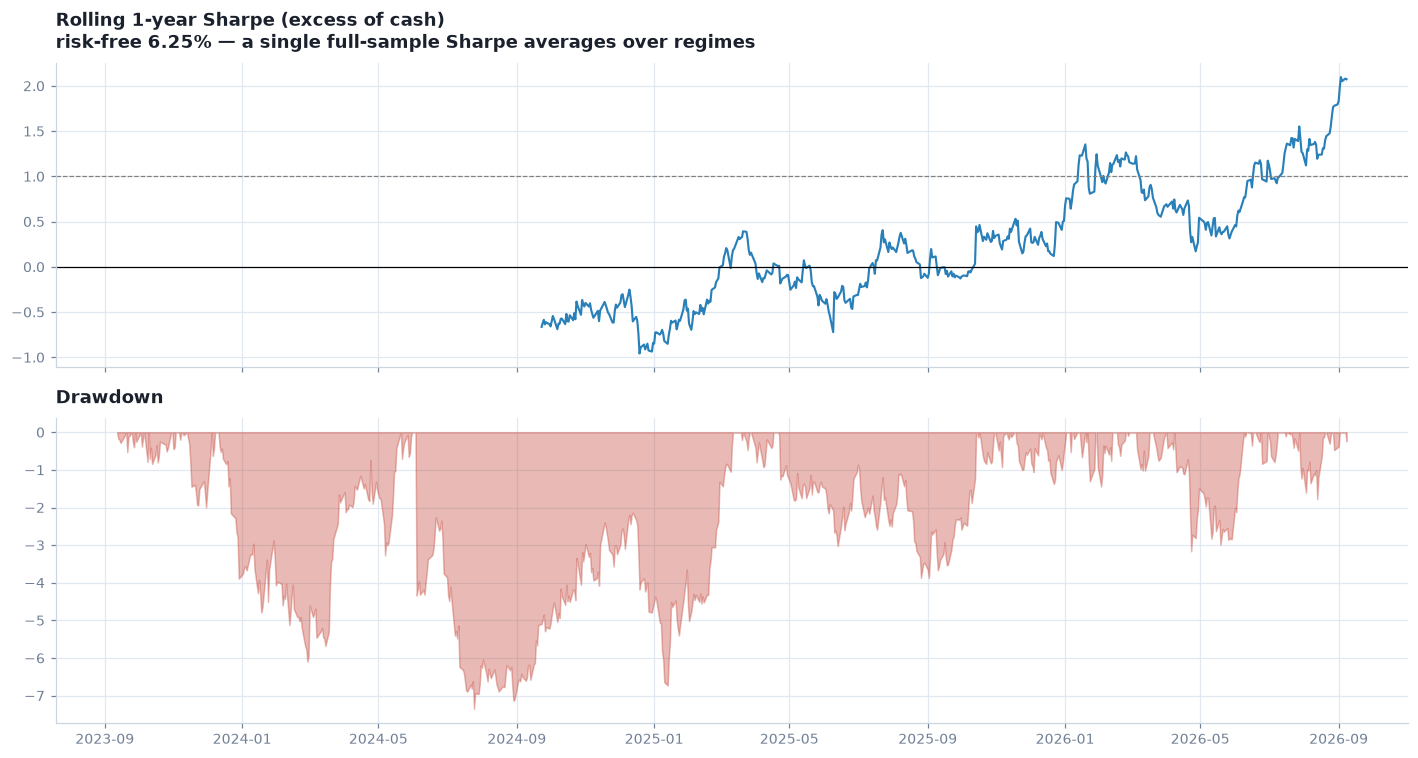

In [11]:
roll = perf.rolling_stats(port_rets, window=252, rf_annual_pct=rf)
if len(roll):
    fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
    axes[0].plot(roll.index, roll["sharpe"], color="#2980b9", lw=1.4)
    axes[0].axhline(0, color="black", lw=0.8)
    axes[0].axhline(1, color="grey", lw=0.8, ls="--")
    viz.title(axes[0], "Rolling 1-year Sharpe (excess of cash)",
              f"risk-free {rf:.2f}% — a single full-sample Sharpe averages over regimes")
    axes[1].fill_between(roll.index, roll["drawdown_%"], 0, color="#c0392b", alpha=0.35)
    viz.title(axes[1], "Drawdown", "")
    plt.tight_layout()
    viz.save(fig, "12_rolling_performance")
    plt.show()
else:
    print("panel too short for a 1-year rolling window")

## 7. Contribution and attribution

Two different decompositions, answering two different questions.

**Contribution** is arithmetic: weight × return, per name. It answers "what made the money".

**Brinson–Fachler attribution** splits the *active* return against a benchmark into the decisions
that produced it — allocation (the sector was over-weighted and the sector did well), selection
(within the sector, the names held beat the sector), and the interaction term. They are different
skills: a period made on allocation says the top-down chain worked, one made on selection says
the scorecard did. Claiming both for one number is how a process stops learning.

Brinson–Fachler is exact only when **both** weight vectors sum to 1. A long/short book sums to
its net exposure — here close to zero — and the identity then fails by a residual that can exceed
the active return it is supposed to explain. A table like that is worse than no table: it looks
precise and reconciles to nothing.

So the long leg is attributed on its own, renormalised to sum to 1, which is the well-posed
question. The short leg is reported separately as a contribution, because that is what it is —
there is no benchmark short book to be active against. `assert_attribution_reconciles` refuses
any attribution whose residual has not closed.

In [12]:
# NOT panel_u.iloc[-1]. `align_to_calendar` never fills past a series' own last
# real observation, so the panel legitimately ends with an all-NaN row whenever
# the current session has not printed yet -- and iloc[-1] then looks exactly like
# "the latest prices" while being a vector of NaN.
period_ret = align.period_return(panel_u)
print(f"period {period_ret.attrs['start'].date()} -> {period_ret.attrs['end'].date()}, "
      f"{period_ret.notna().sum()}/{len(period_ret)} names priced")

contrib = perf.contribution(w, period_ret.reindex(w.index), sectors)
display(contrib.round(4))
print(f"total {contrib.attrs['total_pp']:.2f}pp = long {contrib.attrs['long_pp']:.2f}pp "
      f"+ short {contrib.attrs['short_pp']:.2f}pp | "
      f"{contrib.attrs['n_winners']} winners, {contrib.attrs['n_losers']} losers")

long_leg = w[w > 0]
short_leg = w[w < 0]
short_contrib = float((short_leg * period_ret.reindex(short_leg.index)).sum() * 100)
print()
print(f"short leg contributed {short_contrib:+.2f}pp and is reported separately -- "
      f"there is no benchmark short book for it to be active against.")


period 2023-09-11 -> 2026-09-08, 50/50 names priced


,weight,return_%,contribution_pp,sector,side
ticker,,,,,
ADANIPORTS.NS,0.05,93.78,5.15,Services,long
TITAN.NS,0.08,55.20,4.38,Consumer Durables,long
COALINDIA.NS,0.09,50.65,4.34,Oil Gas & Fuels,long
ICICIBANK.NS,0.09,43.05,4.02,Financial Services,long
JSWSTEEL.NS,0.07,57.39,3.88,Metals & Mining,long
TMPV.NS,-0.07,-51.73,3.53,Automobile,short
HINDUNILVR.NS,-0.12,-21.93,2.63,FMCG,short
WIPRO.NS,-0.11,-21.12,2.38,Information Technology,short
KOTAKBANK.NS,0.08,15.95,1.24,Financial Services,long


total 29.15pp = long 23.02pp + short 6.13pp | 9 winners, 2 losers

short leg contributed +6.13pp and is reported separately -- there is no benchmark short book for it to be active against.


In [13]:
# Benchmark weights: cap-weighted Nifty 50 from the screen's market caps.
bench_w = caps.dropna()
bench_w = bench_w / bench_w.sum()

acts = perf.active_share(w, bench_w)
display(pd.DataFrame([acts]).T.rename(columns={0: "value"}))
print("A long/short book routinely exceeds 100% active share because its shorts have no "
      "benchmark counterpart -- which is why the long-only figure is reported separately.")

# Sector map for the whole universe, not just the book -- the benchmark needs
# every name classified or its sector returns are wrong.
universe_sectors = screen["sector"] if "sector" in screen.columns else sectors

# Attributing the WHOLE long/short book against a long-only benchmark does not
# reconcile. Demonstrated rather than asserted:
try:
    bad = perf.brinson_attribution(w, bench_w, period_ret, universe_sectors)
    perf.assert_attribution_reconciles(bad, label="whole long/short book")
    print("unexpectedly reconciled")
except AssertionError as exc:
    print(f"as expected -- {str(exc)[:230]}")


,value
active_share_%,84.96
long_only_active_share_%,84.96
names_in_book,11.00
names_in_benchmark,50.00
overlap_names,11.00
off_benchmark_weight_%,0.00


A long/short book routinely exceeds 100% active share because its shorts have no benchmark counterpart -- which is why the long-only figure is reported separately.
as expected -- whole long/short book: allocation + selection + interaction = 32.35pp but the active return is -9.98pp -- a residual of -42.34pp. Portfolio weights sum to -0.082, not 1. Attribute the long leg with normalise=True and report the sh


In [14]:
# The long leg on its own, renormalised: a well-posed attribution.
br = perf.brinson_attribution(long_leg, bench_w, period_ret, universe_sectors,
                              normalise=True)
display(br.round(3))
display(perf.assert_attribution_reconciles(br, label="long leg"))
print(f"long leg {br.attrs['portfolio_return_%']:.2f}% vs benchmark "
      f"{br.attrs['benchmark_return_%']:.2f}% -> active "
      f"{br.attrs['active_return_pp']:.2f}pp")
print(f"  allocation {br['allocation_pp'].sum():+.2f}pp | selection "
      f"{br['selection_pp'].sum():+.2f}pp | interaction "
      f"{br['interaction_pp'].sum():+.2f}pp")
print(f"  short leg, reported separately: {short_contrib:+.2f}pp")

,port_weight_%,bench_weight_%,active_weight_pp,port_return_%,bench_return_%,allocation_pp,selection_pp,interaction_pp,total_pp
sector,,,,,,,,,
Information Technology,0.00,9.88,-9.88,0.00,-21.52,5.99,2.13,-2.13,5.99
Services,11.96,2.14,9.81,93.78,93.78,5.36,0.00,0.00,5.36
Oil Gas & Fuels,18.68,12.22,6.46,50.65,13.09,-1.68,4.59,2.43,5.33
Consumer Durables,17.27,3.60,13.68,55.20,27.66,-1.57,0.99,3.77,3.19
FMCG,0.00,6.12,-6.12,0.00,-12.05,3.13,0.74,-0.74,3.13
Metals & Mining,14.73,6.25,8.48,57.39,48.58,0.80,0.55,0.75,2.10
Power,0.00,3.04,-3.04,0.00,35.16,0.12,-1.07,1.07,0.12
Construction,0.00,2.91,-2.91,0.00,36.34,0.08,-1.06,1.06,0.08
Construction Materials,0.00,2.90,-2.90,0.00,49.83,-0.31,-1.44,1.44,-0.31


,active_return_pp,attributed_pp,residual_pp,normalised,result
0,11.01,11.01,-0.00,True,attribution reconciles to the active return


long leg 50.14% vs benchmark 39.13% -> active 11.01pp
  allocation -1.54pp | selection -16.49pp | interaction +29.04pp
  short leg, reported separately: +6.13pp


## 8. Signal

Published to `dashboard.json` as `12_factor_risk`.

In [15]:
payload = {
    "signal": (f"{dec['systematic_share_%']:.0f}% systematic / "
               f"{dec['specific_share_%']:.0f}% specific"),
    "score": round(float(dec["systematic_share_%"]), 1),
    "as_of": str(panel_u.index[-1].date()),
    "risk_free_%": rf,
    "risk_free_source": rf_source,
    "decomposition": dec,
    "top_style_exposure": {
        "factor": str(exposures_book.index[0]),
        "net_exposure": float(exposures_book["net_exposure"].iloc[0]),
    },
    "performance_excess_basis": {
        k: stats.get(k) for k in
        ("cagr_%", "excess_cagr_%", "ann_vol_%", "sharpe", "sortino", "calmar",
         "max_drawdown_%", "rf_annual_%")},
    "sharpe_vs_zero_overstatement": float(
        perf.sharpe_correction(port_rets, rf).loc[0, "overstatement"]),
    "benchmark_relative": {k: rel.get(k) for k in
                           ("beta", "jensen_alpha_ann_%", "tracking_error_ann_%",
                            "information_ratio", "up_capture_%", "down_capture_%")},
    "active_share_%": acts["active_share_%"],
    "factor_model": {
        "n_factors": int(dec["n_factors"]),
        "mean_cross_sectional_r2": float(R2.mean()),
        "n_estimation_dates": int(len(F)),
        "parameters": int(model_cov.attrs["n_parameters"]),
        "sample_parameters": int(model_cov.attrs["n_sample_parameters"]),
    },
}
dashboard.append("12_factor_risk", payload)
display(dashboard.summary())

,notebook,signal,score,as_of,updated_at
0,01_macro,"Goldilocks (growth, cooling prices) | nowcast:...",0.00,2026-09-09,2026-09-09 05:15:44
1,02_risk,Neutral,-0.10,2026-09-08,2026-09-09 05:16:16
2,03_rates,Cautious on duration,-0.27,2026-09-08,2026-09-09 05:16:41
3,04_global_equity,India lagging the world,-39.12,2026-09-09,2026-09-09 05:17:20
4,05_india_market,Mixed,0.23,2026-09-09 10:41:00,2026-09-09 05:18:10
5,06_india_companies,"Top 8 of 50 screened, 6 sectors",80.75,2026-09-09,2026-09-09 05:19:06
6,07_signal_validation,Technical leg: Not proven,-1.62,2026-09-09,2026-09-09 05:23:04
7,08_earnings_quality,"7 do-not-own, 8 short candidates, 43 names pass",51.32,2026-03-31,2026-09-09 05:20:28
8,09_positioning,"12 names scored, 6 short candidates checked fo...",60.19,2026-09-09,2026-09-09 05:20:53
9,10_portfolio,"6L / 5S, gross 0.98x, net -0.06x",6.44,2026-09-09,2026-09-09 05:21:07
